# 慢流形因果涌现案例：双边白化 Koopman 与连续序参量

本 notebook 用一个**二维随机非线性慢快系统**构造一个直观的案例，说明为什么在多稳态/慢流形系统里，双边白化 Koopman 的主导奇异函数可以自然地充当**连续序参量**，并且在**维度平均近似可逆性**意义下出现清晰的因果涌现。

## 本 notebook 要回答的问题

1. 原始二维微观态的相图是否真的呈现出“一条慢流形 + 一个快速横向细节”的几何结构？
2. 在合适观测函数下，双边白化 Koopman 的奇异值谱是否会出现明显的强弱通道分离？
3. 第一奇异函数是否可以被解释为一个连续宏观变量，也就是这个系统的序参量？
4. 若把近似可逆性定义成
   $$
   \bar{\Gamma}_\alpha^K(r)=\frac{1}{r}\sum_{i=1}^r \sigma_i^\alpha,
   $$
   那么 rank-1 宏观表示是否会比微观全维表示具有更高的维度平均可逆性？


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CANDIDATES = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = None
for candidate in CANDIDATES:
    if (candidate / 'exp').exists() and (candidate / 'doc').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('无法定位仓库根目录')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.slow_manifold_ce_case.slow_manifold_ce_case import (
    SlowManifoldConfig,
    analyze_case,
    analyze_observable_modes,
    export_case_figures,
    plot_average_reversibility,
    plot_koopman_matrix_heatmap,
    plot_macro_transition_scatter,
    plot_macro_variable_timeseries,
    plot_mode_singular_spectra,
    plot_phase_portrait,
    plot_phase_portrait_with_drift,
    plot_phi1_on_phase_plane,
    plot_singular_spectrum,
    summarize_analysis,
)

RESULTS_DIR = REPO_ROOT / 'exp' / 'slow_manifold_ce_case' / 'results' / 'slow_manifold_ce_case'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.close('all')


## 1. 系统定义与直觉

我们考虑如下二维随机慢快系统：

$$
\begin{aligned}
 u_{t+1} &= u_t-\varepsilon(u_t^3-u_t)+\sigma_u\,\xi_t,\\
 v_{t+1} &= g(u_t)+\lambda\bigl(v_t-g(u_t)\bigr)+\sigma_v\,\zeta_t,
\end{aligned}
$$

其中
$$
g(u)=u+0.3u^3,
\qquad |\lambda|\ll 1.
$$

直观上：

- `u_t` 是慢变量，控制系统沿双稳态骨架缓慢移动；
- `v_t` 是从变量，会快速收缩到慢流形 $v=g(u)$ 附近；
- 因而二维微观状态虽然连续，但跨时真正稳定传播的信息主要只有一条，即沿慢流形的位置。


,观测模式,维数,观测函数,截断维数,截断平均可逆性,微观全维平均可逆性,截断增益,sigma_1,sigma_2,sigma_3,sigma_4,sigma_5,sigma_6
0,identity,2,"u, v",1,0.9946,0.6384,0.3562,0.9946,0.2821,NaN,NaN,NaN,NaN
1,polynomial,6,"u, v, u^2, uv, v^2, u^3",1,0.9975,0.5535,0.4441,0.9975,0.9624,0.9154,0.2383,0.1257,0.0814
2,fourier,4,"sin(u), cos(u), sin(v), cos(v)",1,0.9973,0.6058,0.3916,0.9973,0.9633,0.3190,0.1435,NaN,NaN


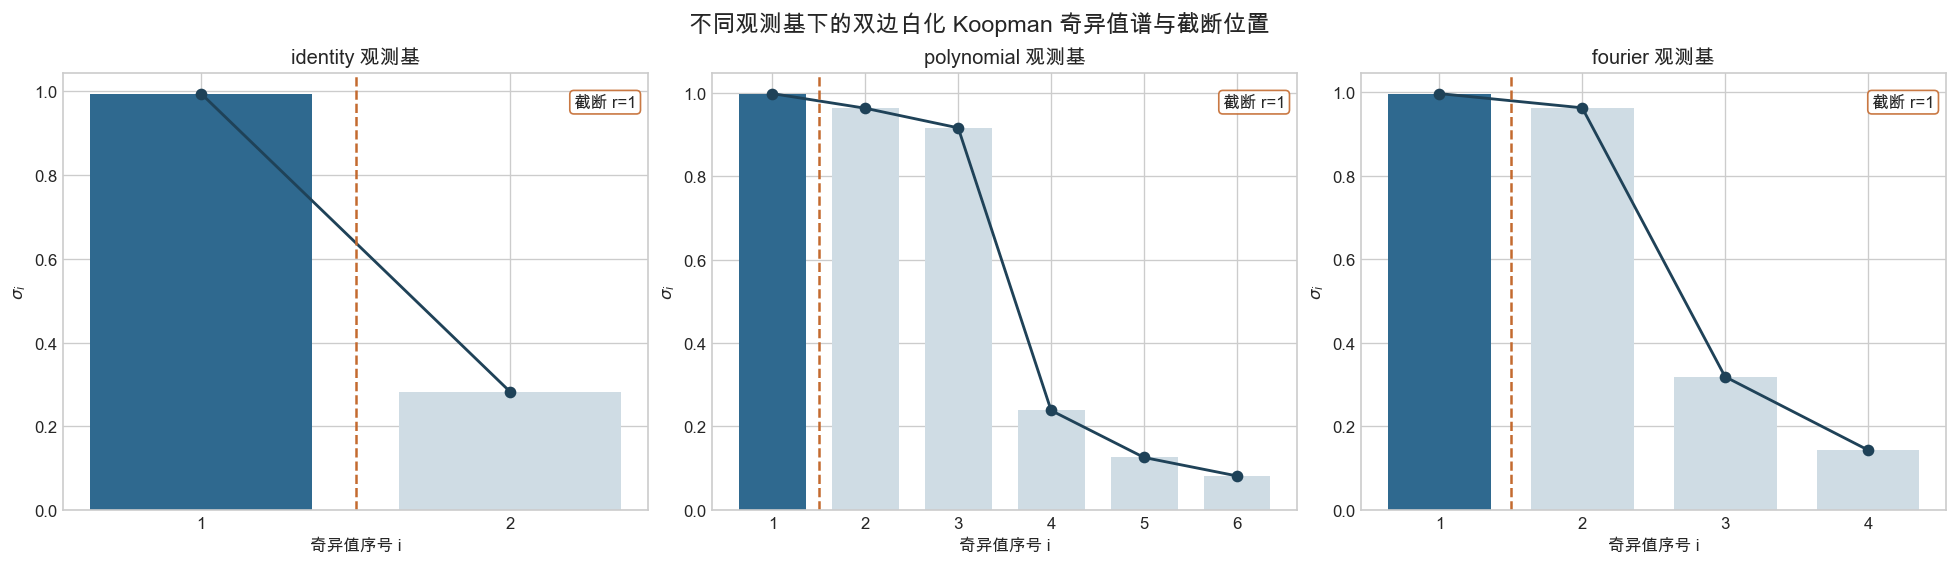

In [2]:
base_kwargs = dict(
    total_steps=6000,
    burn_in=1000,
    seed=23,
    epsilon=0.045,
    sigma_u=0.085,
    sigma_v=0.18,
    lambda_fast=0.12,
    cubic_coupling=0.30,
    u0=-0.8,
    v0_offset=0.6,
    lag_steps=1,
)

mode_comparison = analyze_observable_modes(
    ['identity', 'polynomial', 'fourier'],
    config=SlowManifoldConfig(**base_kwargs, observable_mode='identity'),
)
comparison_df = mode_comparison['comparison_table'].copy()
round_columns = [col for col in comparison_df.columns if col.startswith('sigma_')] + ['截断平均可逆性', '微观全维平均可逆性', '截断增益']
comparison_df[round_columns] = comparison_df[round_columns].round(4)
display(comparison_df)

fig, axes = plot_mode_singular_spectra(
    mode_comparison['mode_results'],
    RESULTS_DIR / 'observable_mode_spectra.png',
)
plt.show()


上表和并排奇异值谱图一起看会更清楚：

- `identity` 只用原始微观坐标 $(u,v)$，假设最少，而且已经能给出非常清楚的 `\sigma_1 \gg \sigma_2` 分离；
- `polynomial` 字典会引入更多高阶通道，因此完整奇异值谱更长，截断前的强通道也更多；
- `fourier` 字典提供了一组完全不同的观测基，适合作为“不是只靠多项式字典才会得到这种现象”的对照。

这里的截断规则统一取
$$
\bar{\Gamma}_\alpha^K(r)=\frac{1}{r}\sum_{i=1}^r \sigma_i^\alpha
$$
的最大值所对应的最小 $r$。因此，谱图里橙色虚线左侧表示“被保留的通道”，右侧表示“被截断的弱通道”。

为了让序参量是从最朴素的微观坐标里自己浮现出来，下面的主案例仍然统一采用最简单的 `identity` 观测函数。


In [3]:
config = SlowManifoldConfig(**base_kwargs, observable_mode='identity')
analysis = mode_comparison['mode_results']['identity']
summary = summarize_analysis(analysis)
summary_df = pd.DataFrame(
    {
        '量': ['sigma_1', 'sigma_2', '截断维数 r_*', '截断平均可逆性', '微观全维平均可逆性', '截断增益'],
        '值': [
            analysis['singular_values'][0],
            analysis['singular_values'][1],
            analysis['truncation_rank'],
            analysis['truncated_average_reversibility'],
            analysis['micro_average_reversibility'],
            analysis['truncated_average_reversibility'] - analysis['micro_average_reversibility'],
        ],
    }
)
summary_df['值'] = summary_df['值'].round(4)
display(summary_df)


,量,值
0,sigma_1,0.9946
1,sigma_2,0.2821
2,截断维数 r_*,1.0000
3,截断平均可逆性,0.9946
4,微观全维平均可逆性,0.6384
5,截断增益,0.3562


## 2. 原始二维相图：先看微观几何

先完全不谈 Koopman，只看轨道在 $(u,v)$ 平面上的几何结构。

如果这个案例成立，我们应该看到两件事：

1. 轨道样本主要堆积在一条弯曲的一维骨架附近；
2. 局部平均漂移箭头大多指向这条骨架，说明横向偏离会很快被忘掉。

这一步是给后面“第一奇异函数就是序参量”做几何铺垫。


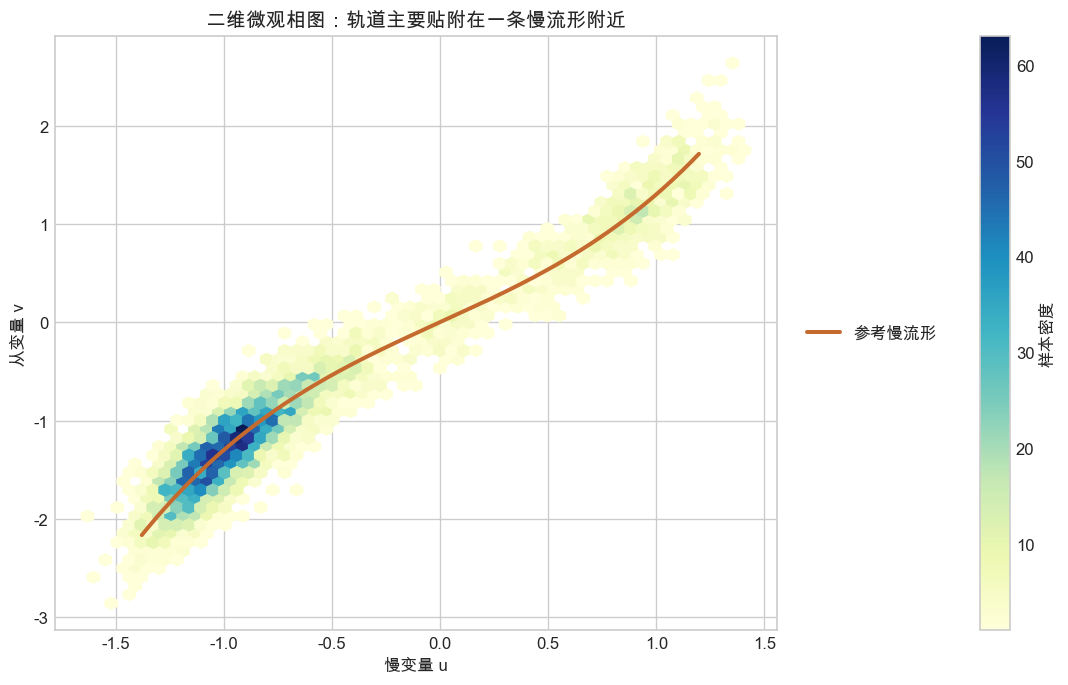

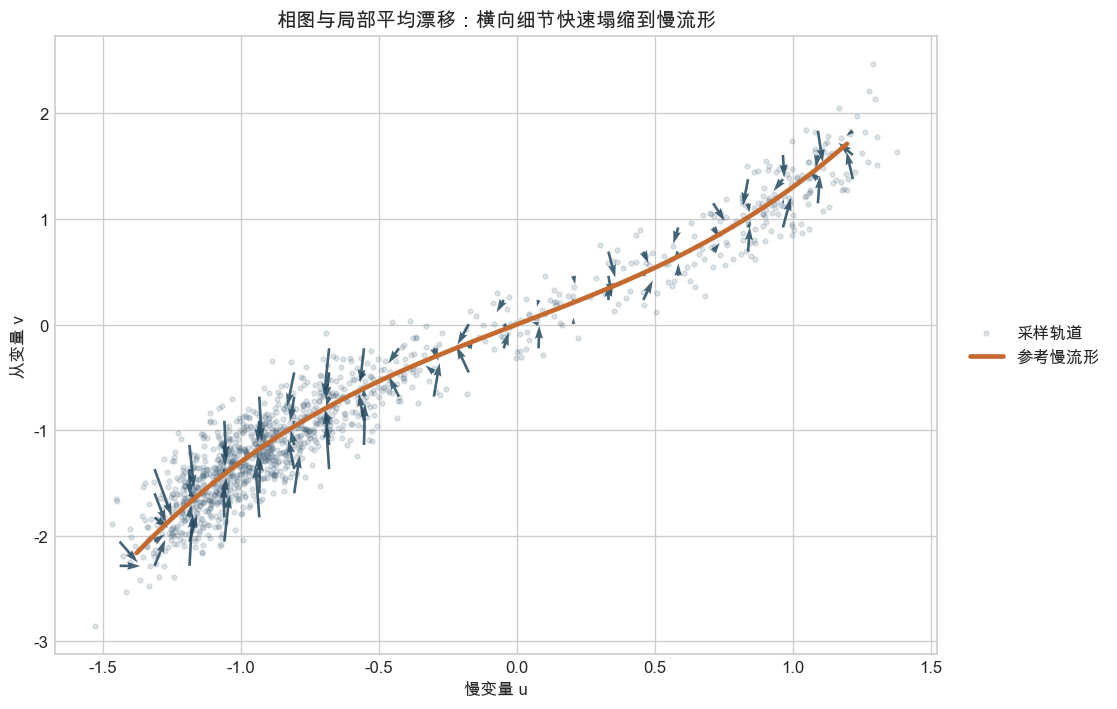

In [4]:
fig, ax = plot_phase_portrait(analysis, RESULTS_DIR / 'phase_portrait.png')
plt.show()

fig, ax = plot_phase_portrait_with_drift(analysis, RESULTS_DIR / 'phase_portrait_with_drift.png')
plt.show()


从相图可以直接读出一个非常直观的故事：

- 虽然微观态是二维连续变量 $(u,v)$；
- 但横向离开慢流形的细节很快就会塌缩；
- 真正持续传播到未来的，主要是“沿慢流形往哪里走”这一个自由度。

换句话说，序参量如果存在，应该更接近**沿慢流形的位置**，而不是整个二维坐标本身。


## 3. 双边白化 Koopman：矩阵、奇异值谱与维度平均可逆性

现在在观测函数
$$
\chi(x)=\begin{bmatrix}u \\ v\end{bmatrix}
$$
下估计
$$
\bar K=C_{00}^{-1/2}C_{01}C_{11}^{-1/2},
$$
并对其做奇异值分解
$$
\bar K = U\operatorname{diag}(\sigma_1,\sigma_2)V^\top.
$$

这里我们特别关心两件事：

1. `\sigma_1` 是否显著大于 `\sigma_2`；
2. rank-1 宏观表示的维度平均近似可逆性
   $$
   \bar{\Gamma}_\alpha^K(1)=\sigma_1^\alpha
   $$
   是否显著高于微观全维平均
   $$
   \bar{\Gamma}_\alpha^K(2)=\frac{\sigma_1^\alpha+\sigma_2^\alpha}{2}.
   $$


,观测函数
0,u
1,v


,奇异值序号 i,sigma_i
0,1,0.9946
1,2,0.2821


,截断量,值
0,r_*,1.0000
1,截断平均可逆性,0.9946


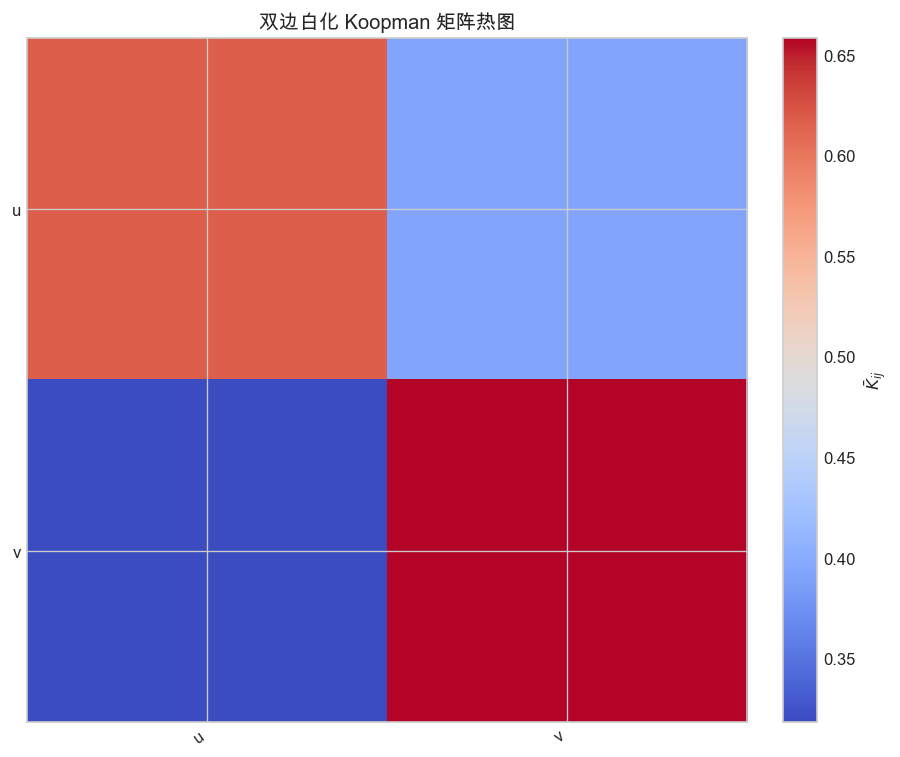

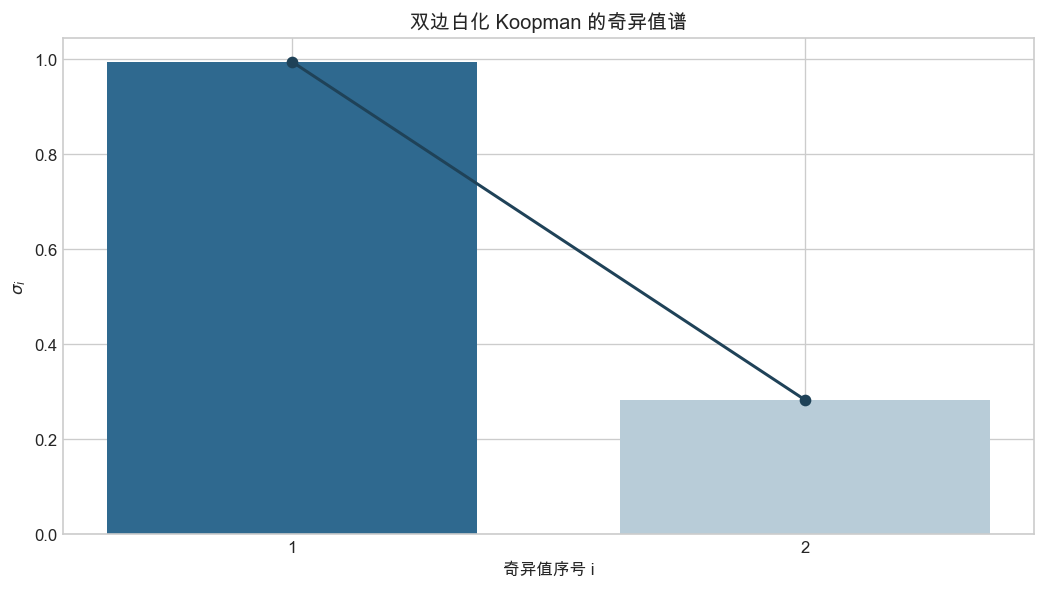

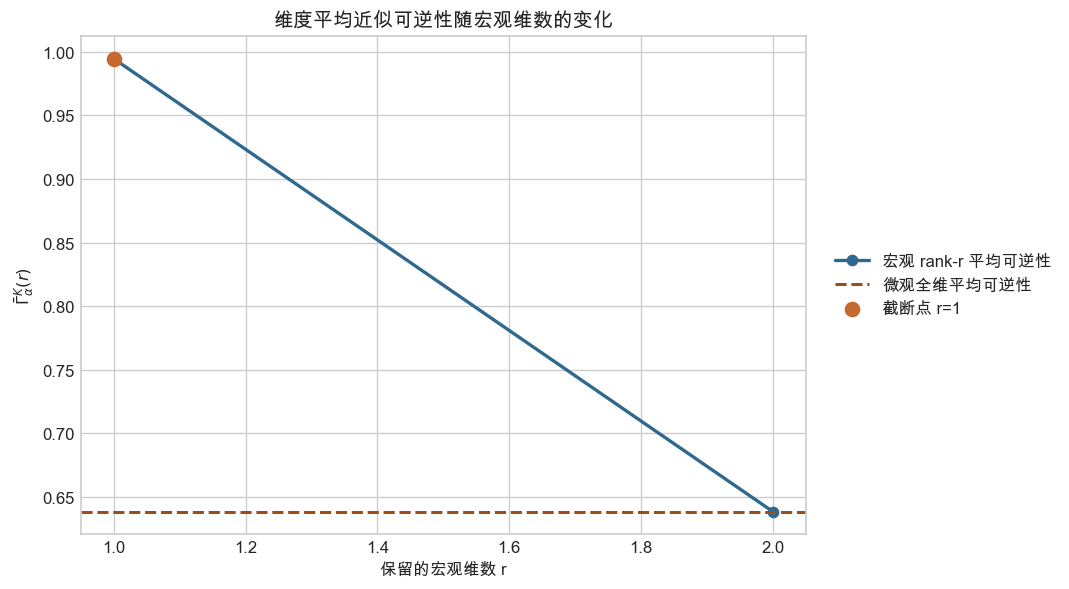

In [5]:
display(pd.DataFrame({'观测函数': analysis['observable_names']}))
display(pd.DataFrame({'奇异值序号 i': np.arange(1, len(analysis['singular_values']) + 1), 'sigma_i': np.round(analysis['singular_values'], 4)}))
display(pd.DataFrame({'截断量': ['r_*', '截断平均可逆性'], '值': [analysis['truncation_rank'], round(analysis['truncated_average_reversibility'], 4)]}))

fig, ax = plot_koopman_matrix_heatmap(analysis, RESULTS_DIR / 'koopman_matrix_heatmap.png')
plt.show()

fig, ax = plot_singular_spectrum(analysis, RESULTS_DIR / 'singular_spectrum.png')
plt.show()

fig, ax = plot_average_reversibility(analysis, RESULTS_DIR / 'avg_reversibility_gain.png')
plt.show()


这一步的解释非常关键：

- 若 `\sigma_1 \gg \sigma_2`，就说明跨时预测结构几乎由一个主导通道控制；
- 在这个例子里，微观层的第二维虽然真实存在，但它主要贡献的是快速遗忘的横向细节；
- 所以删去第二个弱通道之后，宏观层每一维所保留下来的近似可逆性反而更高。

这正是我们要强调的因果涌现叙事：**不是说宏观层拥有更多总信息，而是说宏观层保留下来的每一维都更“值钱”。**


## 4. 第一奇异函数作为粗粒化函数：它是否像连续序参量？

定义当前侧第一奇异函数
$$
\phi_1(x)=u_1^\top C_{00}^{-1/2}\tilde\chi(x).
$$

如果 `\phi_1` 真的是序参量，那么它在相平面上应该表现为：

- 沿慢流形方向平滑变化；
- 横向离开慢流形时变化不大，或者很快被压回；
- 因而它更像“沿骨架走到哪里”，而不是“此刻所有二维细节的完整描述”。


,指标,值
0,"corr(phi_1(x_t), u_t)",0.9999
1,"corr(phi_1(x_t), v_t)",0.9687


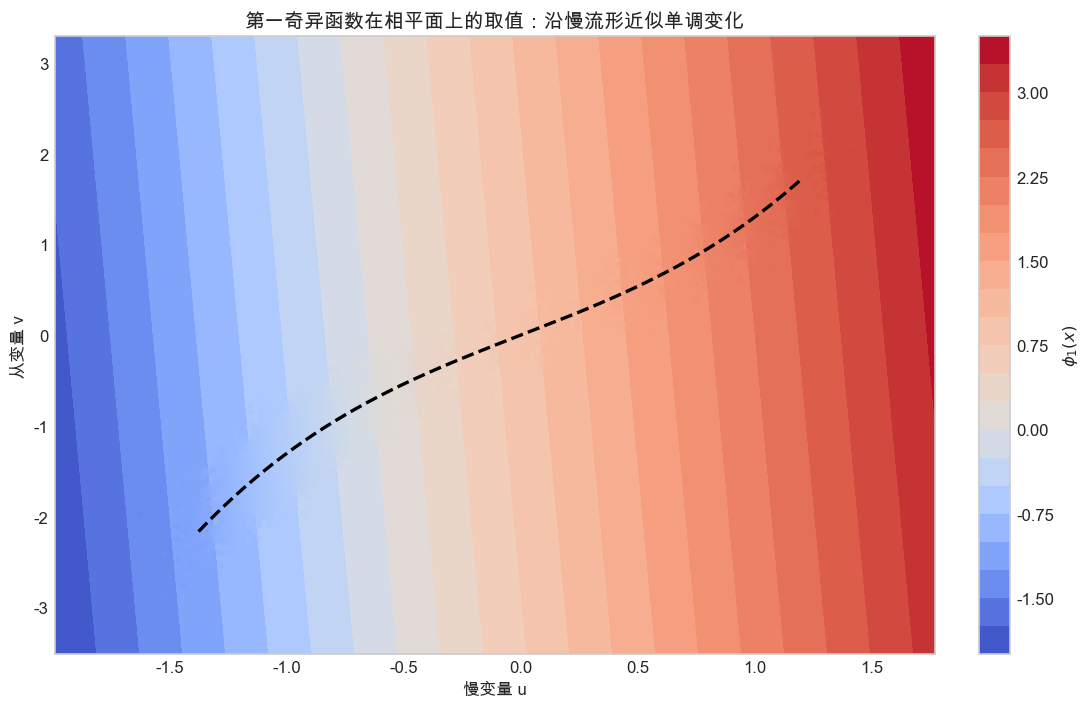

In [6]:
phi_summary = pd.DataFrame(
    {
        '指标': ['corr(phi_1(x_t), u_t)', 'corr(phi_1(x_t), v_t)'],
        '值': [
            np.corrcoef(analysis['phi1_values'], analysis['current_states'][:, 0])[0, 1],
            np.corrcoef(analysis['phi1_values'], analysis['current_states'][:, 1])[0, 1],
        ],
    }
)
phi_summary['值'] = phi_summary['值'].round(4)
display(phi_summary)

fig, ax = plot_phi1_on_phase_plane(analysis, RESULTS_DIR / 'phi1_on_phase_plane.png')
plt.show()


这张热图是整个案例里最重要的一张图之一。

如果你把颜色理解为宏观变量 $z_t=\phi_1(x_t)$ 的数值，那么它几乎就是在给慢流形上的点做“位置编码”：

- 左侧稳态盆附近对应一段颜色范围；
- 右侧稳态盆附近对应另一段颜色范围；
- 中间过渡区沿着慢流形连续变化。

所以，第一奇异函数并不是随便一个抽象投影，而是非常接近这个系统的**连续序参量**。


## 5. 宏观变量可视化：从相图颜色到跨时散点图

最后把
$$
z_t = \phi_1(x_t)
$$
当成一个真正的宏观变量来看。

我们希望看到：

1. $z_t$ 的时间演化和原始慢变量 $u_t$ 有明显同步关系；
2. 与从变量 $v_t$ 相比，$z_t$ 更稳定地抓住长期结构；
3. 在跨时散点图 $(z_t, z_{t+\tau}^{+})$ 上，主导宏观通道会显得更紧、更接近一维关系。


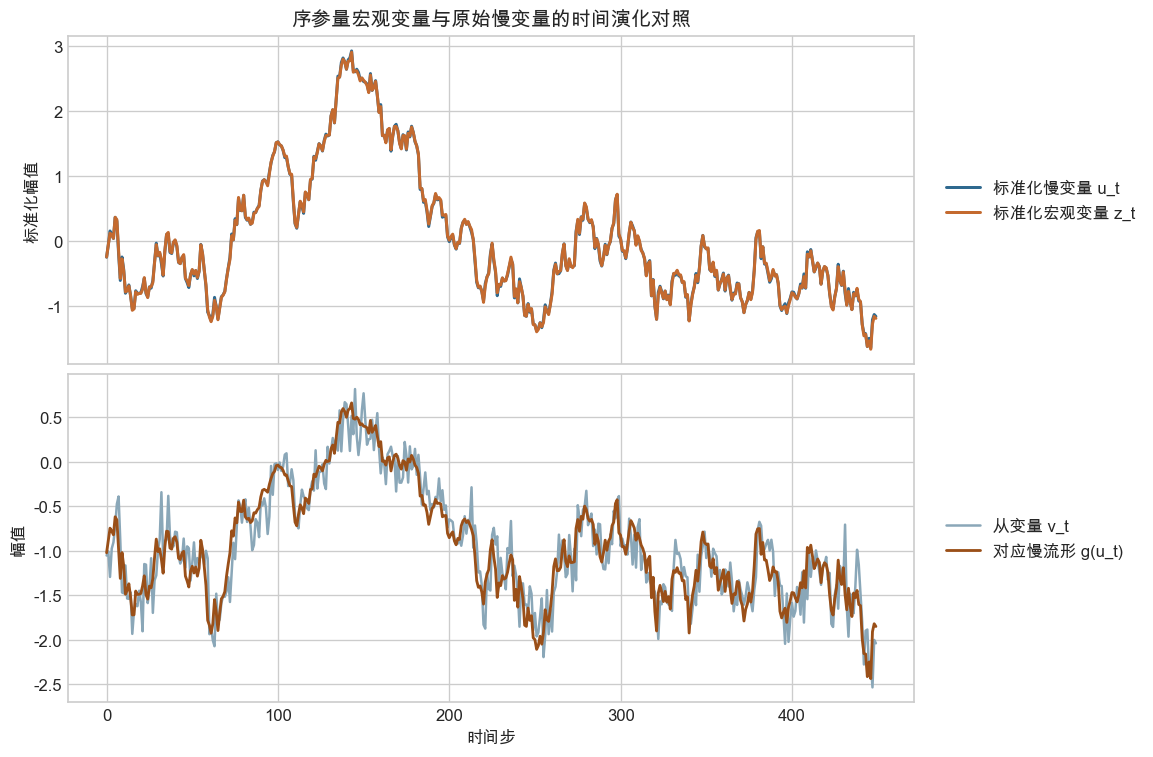

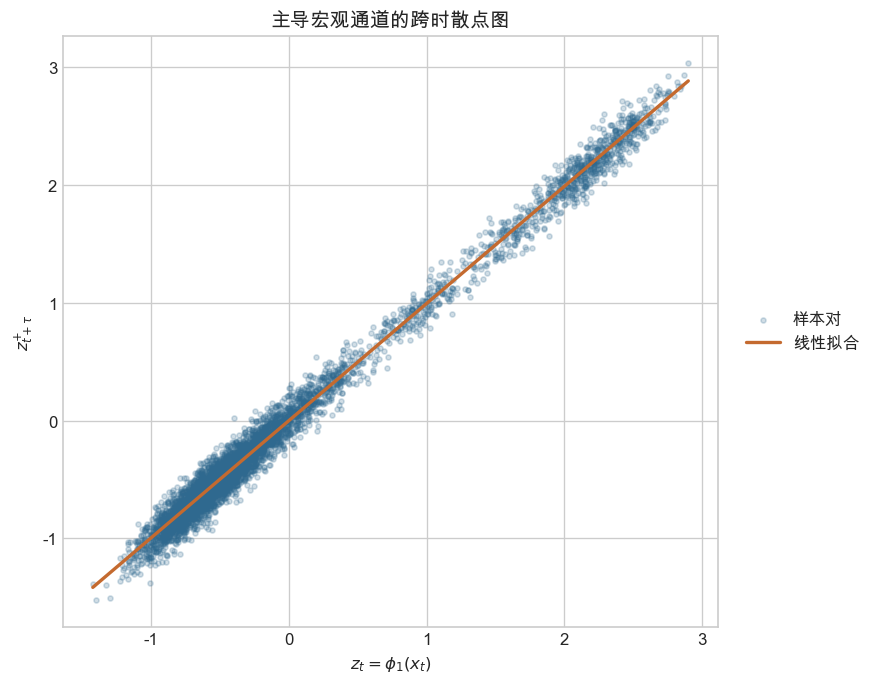

In [7]:
fig, axes = plot_macro_variable_timeseries(analysis, RESULTS_DIR / 'macro_variable_timeseries.png')
plt.show()

fig, ax = plot_macro_transition_scatter(analysis, RESULTS_DIR / 'zt_vs_ztau.png')
plt.show()


In [8]:
artifact_paths = export_case_figures(analysis, RESULTS_DIR)
artifact_paths['observable_mode_spectra'] = str(RESULTS_DIR / 'observable_mode_spectra.png')
artifact_df = pd.DataFrame(
    {
        '产物': list(artifact_paths.keys()),
        '路径': [str(path.relative_to(REPO_ROOT)) for path in map(Path, artifact_paths.values())],
    }
)
artifact_df


,产物,路径
0,phase_portrait,exp/slow_manifold_ce_case/results/slow_manifol...
1,phase_portrait_with_drift,exp/slow_manifold_ce_case/results/slow_manifol...
2,koopman_matrix_heatmap,exp/slow_manifold_ce_case/results/slow_manifol...
3,singular_spectrum,exp/slow_manifold_ce_case/results/slow_manifol...
4,avg_reversibility_gain,exp/slow_manifold_ce_case/results/slow_manifol...
5,phi1_on_phase_plane,exp/slow_manifold_ce_case/results/slow_manifol...
6,macro_variable_timeseries,exp/slow_manifold_ce_case/results/slow_manifol...
7,zt_vs_ztau,exp/slow_manifold_ce_case/results/slow_manifol...
8,summary_metrics,exp/slow_manifold_ce_case/results/slow_manifol...
9,observable_mode_spectra,exp/slow_manifold_ce_case/results/slow_manifol...


## 6. 结论整理

这个例子之所以有说服力，是因为它把“序参量”这件事拆成了几层彼此支撑的证据：

1. **几何证据**：原始二维相图显示轨道主要贴附在一条慢流形附近，横向细节会快速遗忘。
2. **谱证据**：双边白化 Koopman 的奇异值谱呈现 `\sigma_1 \gg \sigma_2`，说明真正稳定的跨时通道几乎只有一个。
3. **函数证据**：第一奇异函数 `\phi_1(x)` 在相平面上沿慢流形近似单调变化，因此可以直接当作连续粗粒化函数。
4. **宏观证据**：定义宏观变量 `z_t=\phi_1(x_t)` 后，rank-1 宏观层的维度平均近似可逆性显著高于微观全维平均值。

因此，对这个具体的随机非线性系统而言，按照双边白化 Koopman 的主导奇异函数来定义宏观变量，确实能够识别出清晰的连续序参量，并在维度平均可逆性意义下表现出明确的因果涌现。
